## In Class Activity April 21st

In [182]:
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
import category_encoders as ce
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

C:\miniforge3\envs\machine-learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [48]:
METRIC = "balanced_accuracy"
METRIC_FUNC = balanced_accuracy_score

## Load & Prep Data

In [49]:
# load data
df = pd.read_csv("../data/adult.csv")

# convert "?" -> NaN
df = df.replace("?", np.nan)

# convert target variable to binary
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in df.columns:
    df["gender"] = df["gender"].apply(lambda x: 1 if x == "Male" else 0)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [50]:
# fixed train/test split for the entire notebook
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df["income"],
    random_state=42
)

# for cross validation - maintain the same splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


# Base Modeling

## Model 1 - `RandomForest`

- no scaling required
- must encode categorical variables

### Preprocessing

In [51]:
# how many unique values are there in each categorical
df.select_dtypes(include='str').nunique().sort_values(ascending=False)

native-country    41
education         16
occupation        14
workclass          8
marital-status     7
relationship       6
race               5
dtype: int64

In [52]:
# encode categorical variables
df_encoded = df.copy()

# dummify low cardinality (<10) cats
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True,
    dtype=int
)

# target encode high cardinality (>=10) variables
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
df_encoded["occupation_encoded"] = occupation_encoder.fit_transform(
    X=df_encoded[["occupation"]],
    y=df_encoded["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
df_encoded["native_county_encoded"] = native_country_encoder.fit_transform(
    X=df_encoded[["native-country"]],
    y=df_encoded["income"]
)["native-country"]

df_encoded.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_county_encoded
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,0,0,0,1,0,0,0,0,0.123097,0.243977
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,1,0,0,1,0,0,0,0,0.116107,0.243977
2,28,336951,Assoc-acdm,12,Protective-serv,1,0,0,40,United-States,...,1,1,0,0,0,0,0,0,0.313327,0.243977
3,44,160323,Some-college,10,Machine-op-inspct,1,7688,0,40,United-States,...,0,0,0,1,0,0,0,0,0.123097,0.243977
4,18,103497,Some-college,10,NaN,0,0,0,30,United-States,...,1,0,0,0,0,0,0,0,0.094340,0.243977


In [53]:
# get training & testing data
X = df_encoded.drop(columns=[
    "income",
    "occupation",
    "fnlwgt",
    "education", # we have a numeric proxy for this
    "native-country"
])

y = df_encoded["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

### Training

In [54]:
# declare model spec
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# cv on training data before fitting
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")

# fit
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_metric_score = METRIC_FUNC(y_test, rf_preds)
print(f"{METRIC}: {rf_metric_score:.4f}")

cv scores: 0.7742 +/- 0.0048
balanced_accuracy: 0.7799


## Model 2 -  SVM

- scaling required
- must encode categorical features

### Preprocessing

- we can use `df_encoded`, but we need to scale the data as well

In [55]:
# get training & testing data
X = df_encoded.drop(columns=[
    "income",
    "occupation",
    "fnlwgt",
    "education", # we have a numeric proxy for this
    "native-country"
])

y = df_encoded["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

### Training

In [56]:
# declare model spec
ct = ColumnTransformer([("std", StandardScaler(), make_column_selector(dtype_include="number"))])
svm = Pipeline(
    [
        ("ct", ct),
        ("svm", SVC(random_state=42, kernel="rbf")) # nonlinear kernel
    ]
)

# cv on training data before fitting
svm_cv_scores = cross_val_score(svm, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {svm_cv_scores.mean():.4f} +/- {svm_cv_scores.std():.4f}")

# fit
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

svm_metric_score = METRIC_FUNC(y_test, svm_preds)
print(f"{METRIC}: {svm_metric_score:.4f}")

cv scores: 0.7510 +/- 0.0051
balanced_accuracy: 0.7584


## Model 3 - LightGBM

- tree-based: no scaling
- can handle categorical features automatically


### Preprocessing

In [57]:
df_lgbm = df.copy()

cat_cols = df_lgbm.select_dtypes("str").columns
df_lgbm[cat_cols] = df_lgbm[cat_cols].astype("category")

df_lgbm.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [90]:
# get training & testing data
# for some reason leaving both education vars gives a slight boost to performance
X = df_lgbm.drop(columns=[
    "income",
    "fnlwgt",
])

y = df_lgbm["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

### Training

In [91]:
# declare model spec
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, class_weight="balanced", verbosity=0)

# cv on training data before fitting
lgbm_cv_scores = cross_val_score(lgbm, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {lgbm_cv_scores.mean():.4f} +/- {lgbm_cv_scores.std():.4f}")

# fit
lgbm.fit(X_train, y_train)
lgbm_preds = lgbm.predict(X_test)

lgbm_metric_score = METRIC_FUNC(y_test, lgbm_preds)
print(f"{METRIC}: {lgbm_metric_score:.4f}")

cv scores: 0.8443 +/- 0.0040
balanced_accuracy: 0.8435


## Overall Base Model Evaluations

In [180]:
base_results = pd.DataFrame({
    "mean_cv_score": [rf_cv_scores.mean(), svm_cv_scores.mean(), lgbm_cv_scores.mean()],
    "std_cv_score": [rf_cv_scores.std(), svm_cv_scores.std(), lgbm_cv_scores.std()],
    "balanced_accuracy": [rf_metric_score, svm_metric_score, lgbm_metric_score]
}, index=["RandomForest", "SVM", "LightGBM"]).round(4).sort_values("balanced_accuracy", ascending=False)

base_results

,mean_cv_score,std_cv_score,balanced_accuracy
LightGBM,0.8443,0.0040,0.8435
RandomForest,0.7742,0.0048,0.7799
SVM,0.7510,0.0051,0.7584


### Inspect Errors

- gray bars show relative volume of that attribute.

- really interesting that LightGBM seems to have the highest error in most categories and at most ranges for numeric features...and yet it outperforms the other models by a significant margin.
- likewise, the svm seems to have the lowest errors across those same fields and it performed horribly
- ps: this might be because "error" here is defined as `accuracy` while we evaluated models on `balanced_accuracy`

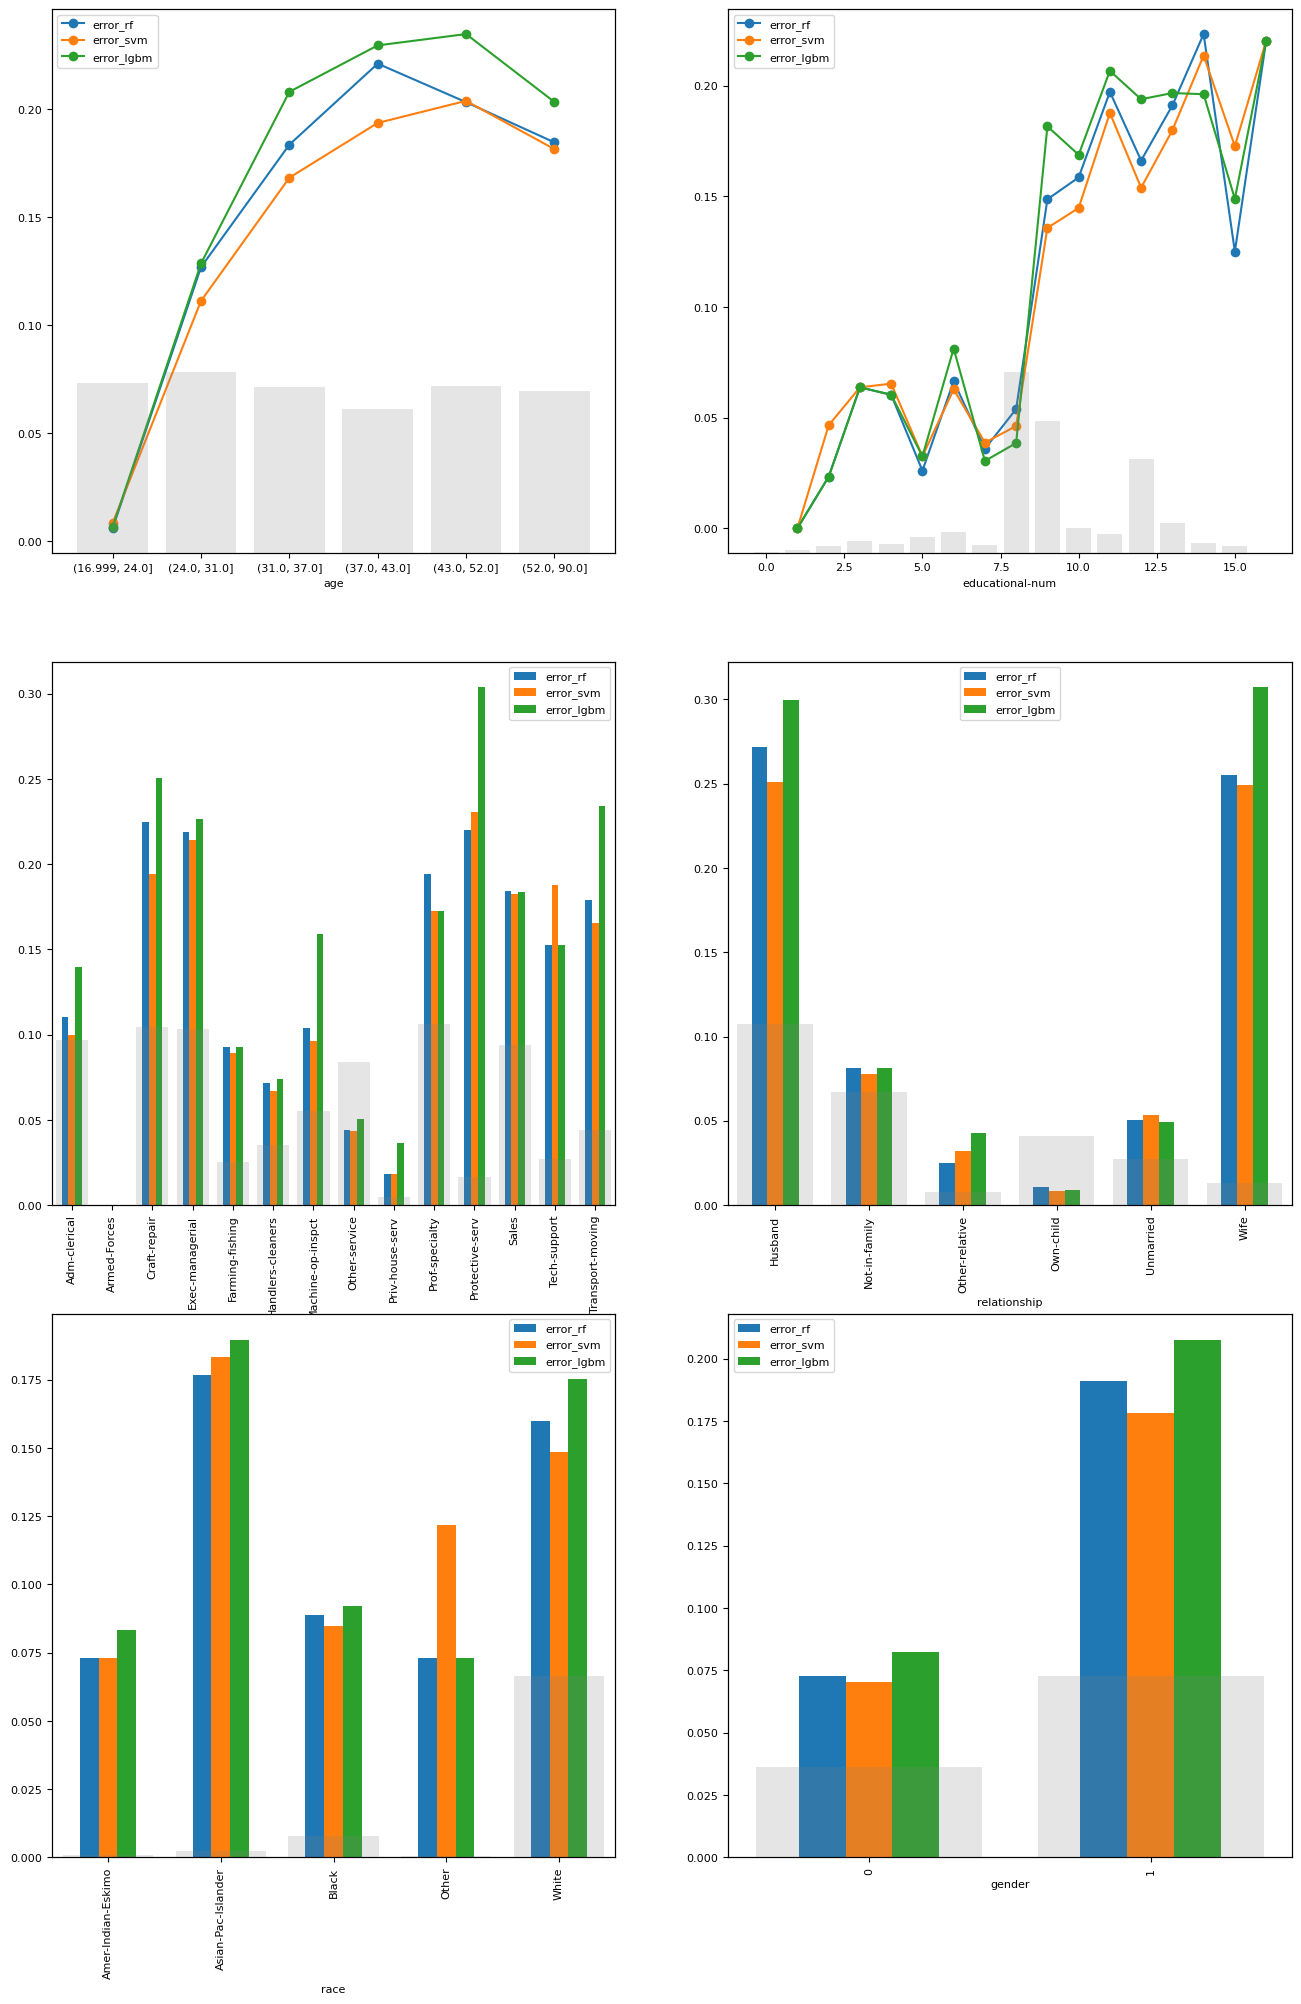

In [122]:
df_err = X_test.copy()
df_err["y_true"] = y_test
df_err["error_rf"] = (rf_preds != y_test).astype(int)
df_err["error_svm"] = (svm_preds != y_test).astype(int)
df_err["error_lgbm"] = (lgbm_preds != y_test).astype(int)


plt.rcParams["font.size"] = 8

fig, axes = plt.subplots(figsize=(16, 24), ncols=2, nrows=3)
axes = axes.flatten()

# age
bins_age = pd.qcut(df_err["age"], q=6)
grouped_age = df_err.groupby(bins_age)
errors_age = grouped_age[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_age = grouped_age.size()

errors_age.plot(kind="line", ax=axes[0], marker="o")

ax2 = axes[0].twinx()
ax2.bar(range(len(counts_age)), counts_age, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_age.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])

# education years
grouped_edu = df_err.groupby("educational-num")
errors_edu = grouped_edu[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_edu = grouped_edu.size()

errors_edu.plot(kind="line", ax=axes[1], marker="o")

ax2 = axes[1].twinx()
ax2.bar(range(len(counts_edu)), counts_edu, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_edu.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])

# occupation years
grouped_occ = df_err.groupby("occupation")
errors_occ = grouped_occ[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_occ = grouped_occ.size()

errors_occ.plot(kind="bar", ax=axes[2])

ax2 = axes[2].twinx()
ax2.bar(range(len(counts_occ)), counts_occ, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_occ.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])

# relationship years
grouped_relation = df_err.groupby("relationship")
errors_relation = grouped_relation[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_relation = grouped_relation.size()

errors_relation.plot(kind="bar", ax=axes[3])

ax2 = axes[3].twinx()
ax2.bar(range(len(counts_relation)), counts_relation, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_relation.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])

# race
grouped_race = df_err.groupby("race")
errors_race = grouped_race[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_race = grouped_race.size()

errors_race.plot(kind="bar", ax=axes[4])

ax2 = axes[4].twinx()
ax2.bar(range(len(counts_race)), counts_race, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_race.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])

# gender
grouped_gender = df_err.groupby("gender")
errors_gender = grouped_gender[["error_rf", "error_svm", "error_lgbm"]].mean()
counts_gender = grouped_gender.size()

errors_gender.plot(kind="bar", ax=axes[5])

ax2 = axes[5].twinx()
ax2.bar(range(len(counts_gender)), counts_gender, alpha=0.2, color="gray", zorder=0)
ax2.set_ylim(0, counts_gender.max() * 3)  # squash bars into lower portion so they don't fight the lines
ax2.set_yticks([])


plt.show()

# Create New Features

In [162]:
df_eng = df.copy()

# missing ness
df_eng = df_eng.assign(
    missing_workclass=(pd.isna(df["workclass"])).astype(int),
    missing_occupation=(pd.isna(df["occupation"])).astype(int)
)

df_eng["net_capital"] = df_eng["capital-gain"] - df_eng["capital-loss"]
df_eng["age_binned"] = pd.qcut(df_eng["age"], q=10).astype("category")
df_eng["is_overtime_worker"] = (df_eng["hours-per-week"] > 40).astype(int)

# Evaluate New Features

## Model 1 - RandomForest

### Preprocessing

In [163]:
# encode categorical variables
df_eng_encoded = df_eng.copy()
# dummify low cardinality (<10) cats
df_eng_encoded = pd.get_dummies(
    df_eng_encoded,
    columns=["marital-status", "relationship", "race", "workclass", "age_binned"],
    drop_first=True,
    dtype=int
)

# target encode high cardinality (>=10) variables
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
df_eng_encoded["occupation_encoded"] = occupation_encoder.fit_transform(
    X=df_eng_encoded[["occupation"]],
    y=df_eng_encoded["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
df_eng_encoded["native_county_encoded"] = native_country_encoder.fit_transform(
    X=df_eng_encoded[["native-country"]],
    y=df_eng_encoded["income"]
)["native-country"]

In [164]:
# get training & testing data
X = df_eng_encoded.drop(columns=[
    "income",
    "age",
    "occupation",
    "fnlwgt",
    "capital-gain",
    "capital-loss",
    "education", # we have a numeric proxy for this
    "native-country"
])

y = df_eng_encoded["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

X_train.head()

,educational-num,gender,hours-per-week,missing_workclass,missing_occupation,net_capital,is_overtime_worker,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,...,"age_binned_(26.0, 30.0]","age_binned_(30.0, 33.0]","age_binned_(33.0, 37.0]","age_binned_(37.0, 41.0]","age_binned_(41.0, 45.0]","age_binned_(45.0, 51.0]","age_binned_(51.0, 58.0]","age_binned_(58.0, 90.0]",occupation_encoded,native_county_encoded
34342,9,1,17,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0.066602,0.243977
18559,6,0,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.267987,0.243977
12477,9,1,40,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0.041438,0.070968
560,9,0,40,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0.136874,0.243977
3427,13,1,40,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0.477818,0.243977


### Training

In [165]:
# declare model spec
rf_v2 = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# cv on training data before fitting
rf_v2_cv_scores = cross_val_score(rf_v2, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {rf_v2_cv_scores.mean():.4f} +/- {rf_v2_cv_scores.std():.4f}")

# fit
rf_v2.fit(X_train, y_train)
rf_v2_preds = rf_v2.predict(X_test)

rf_v2_metric_score = METRIC_FUNC(y_test, rf_v2_preds)
print(f"{METRIC}: {rf_v2_metric_score:.4f}")

cv scores: 0.7797 +/- 0.0034
balanced_accuracy: 0.7921


## Model 2 - SVM

### Preprocessing

In [ ]:
# na

### Training

In [166]:
# declare model spec
ct = ColumnTransformer([("std", StandardScaler(), make_column_selector(dtype_include="number"))])
svm_v2 = Pipeline(
    [
        ("ct", ct),
        ("svm_v2", SVC(random_state=42, kernel="rbf")) # nonlinear kernel
    ]
)

# cv on training data before fitting
svm_v2_cv_scores = cross_val_score(svm_v2, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {svm_v2_cv_scores.mean():.4f} +/- {svm_v2_cv_scores.std():.4f}")

# fit
svm_v2.fit(X_train, y_train)
svm_v2_preds = svm_v2.predict(X_test)

svm_v2_metric_score = METRIC_FUNC(y_test, svm_v2_preds)
print(f"{METRIC}: {svm_metric_score:.4f}")

cv scores: 0.7436 +/- 0.0073
balanced_accuracy: 0.7584


## Model 3 - LightGBM

### Preprocessing

In [170]:
# get training & testing data
X = df_eng.drop(columns=[
    "income",
    "fnlwgt",
    "capital-gain",
    "capital-loss",
    "age_binned",
    "education", # we have a numeric proxy for this
])

cat_cols = X.select_dtypes("str").columns
X[cat_cols] = X[cat_cols].astype("category")

y = df_eng["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

X_train.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,missing_workclass,missing_occupation,net_capital,is_overtime_worker
34342,71,Private,9,Never-married,Handlers-cleaners,Not-in-family,White,1,17,United-States,0,0,0,0
18559,17,Private,6,Never-married,Sales,Other-relative,White,0,10,United-States,0,0,0,0
12477,27,Private,9,Married-civ-spouse,Other-service,Husband,White,1,40,El-Salvador,0,0,0,0
560,43,Private,9,Separated,Adm-clerical,Unmarried,Black,0,40,United-States,0,0,0,0
3427,31,Private,13,Married-civ-spouse,Exec-managerial,Husband,White,1,40,United-States,0,0,0,0


### Training

In [171]:
# declare model spec
lgbm_v2 = LGBMClassifier(random_state=42, class_weight="balanced", verbosity=0)

# cv on training data before fitting
lgbm_v2_cv_scores = cross_val_score(lgbm_v2, X_train, y_train, cv=skf, scoring=METRIC, n_jobs=-1)
print(f"cv scores: {lgbm_v2_cv_scores.mean():.4f} +/- {lgbm_v2_cv_scores.std():.4f}")

# fit
lgbm_v2.fit(X_train, y_train)
lgbm_v2_preds = lgbm_v2.predict(X_test)

lgbm_v2_metric_score = METRIC_FUNC(y_test, lgbm_v2_preds)
print(f"{METRIC}: {lgbm_v2_metric_score:.4f}")

cv scores: 0.8445 +/- 0.0030
balanced_accuracy: 0.8452


## New Feature Evaluations

In [179]:
eng_results = pd.DataFrame({
    "mean_cv_score": [rf_v2_cv_scores.mean(), svm_v2_cv_scores.mean(), lgbm_v2_cv_scores.mean()],
    "std_cv_score": [rf_v2_cv_scores.std(), svm_v2_cv_scores.std(), lgbm_v2_cv_scores.std()],
    "balanced_accuracy": [rf_v2_metric_score, svm_v2_metric_score, lgbm_v2_metric_score]
}, index=["RandomForest", "SVM", "LightGBM"]).round(4).sort_values("balanced_accuracy", ascending=False)

eng_results

,mean_cv_score,std_cv_score,balanced_accuracy
LightGBM,0.8445,0.0030,0.8452
RandomForest,0.7797,0.0034,0.7921
SVM,0.7436,0.0073,0.7570


In [181]:
# diffs
eng_results - base_results

,mean_cv_score,std_cv_score,balanced_accuracy
LightGBM,0.0002,-0.0010,0.0017
RandomForest,0.0055,-0.0014,0.0122
SVM,-0.0074,0.0022,-0.0014


# Finetuning

## Tune RandomForest

In [197]:
# get training & testing data
X = df_eng_encoded.drop(columns=[
    "income",
    "age",
    "occupation",
    "fnlwgt",
    "capital-gain",
    "capital-loss",
    "education", # we have a numeric proxy for this
    "native-country"
])

y = df_eng_encoded["income"]

X_train_rf = X.loc[train_idx]
X_test_rf = X.loc[test_idx]
y_train_rf = y.loc[train_idx]
y_test = y.loc[test_idx]

In [191]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 5, 500)
    max_depth = trial.suggest_int('max_depth', 1, 100)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    rf_optuna = RandomForestClassifier(
                    random_state=42,
                    class_weight="balanced",
                    n_jobs=-1,
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    max_features=max_features,
                    min_samples_leaf=min_samples_leaf
                )

    cv_scores = cross_val_score(rf_optuna, X_train_rf, y_train_rf, cv=skf, scoring='balanced_accuracy')
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-04-21 17:51:49,781] A new study created in memory with name: no-name-620982af-f19a-4673-b5e7-5d2d9736700e
[I 2026-04-21 17:51:50,741] Trial 0 finished with value: 0.8241345486649667 and parameters: {'n_estimators': 63, 'max_depth': 55, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8241345486649667.
[I 2026-04-21 17:51:56,046] Trial 1 finished with value: 0.8298023168706845 and parameters: {'n_estimators': 426, 'max_depth': 58, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8298023168706845.
[I 2026-04-21 17:51:58,435] Trial 2 finished with value: 0.8237910770688185 and parameters: {'n_estimators': 220, 'max_depth': 11, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.8298023168706845.
[I 2026-04-21 17:51:59,906] Trial 3 finished with value: 0.8295420268906198 and parameters: {'n_estimators': 120, 'max_depth': 37, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value:

In [198]:
best_rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    **study.best_params
)

best_rf.fit(X_train_rf, y_train_rf)
best_rf_preds = best_rf.predict_proba(X_test_rf)

In [223]:
pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

,feature,importance
8,marital-status_Married-civ-spouse,1.951640e-01
38,occupation_encoded,1.256943e-01
0,educational-num,1.233640e-01
5,net_capital,1.154029e-01
10,marital-status_Never-married,1.112089e-01
2,hours-per-week,5.561137e-02
13,relationship_Not-in-family,3.458854e-02
15,relationship_Own-child,3.178411e-02
6,is_overtime_worker,2.915129e-02
1,gender,2.629849e-02


## Tune SVM

In [ ]:
# this will take eons and im almost certain it will not be good. we are skipping this.

## Tune LightGBM

In [200]:
# get training & testing data
X = df_eng.drop(columns=[
    "income",
    "fnlwgt",
    "capital-gain",
    "capital-loss",
    "age_binned",
    "education", # we have a numeric proxy for this
])

cat_cols = X.select_dtypes("str").columns
X[cat_cols] = X[cat_cols].astype("category")

y = df_eng["income"]

X_train_gbm = X.loc[train_idx]
X_test_gbm = X.loc[test_idx]
y_train_gbm = y.loc[train_idx]
y_test = y.loc[test_idx]

In [201]:
# tuning with Optuna (tune more parameters than shown here)
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 5, 500)
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 0, 10)
    max_depth = trial.suggest_int('max_depth', -1, 100)
    learning_rate = trial.suggest_float('learning_rate', 0.3, 0.5)
    alpha = trial.suggest_float("alpha", 0, 3)

    lgbm_optuna = LGBMClassifier(
                    random_state=42,
                    verbosity=0,
                    n_estimators=n_estimators,
                    scale_pos_weight=scale_pos_weight,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    alpha=alpha,
                )

    cv_scores = cross_val_score(lgbm_optuna, X_train_gbm, y_train_gbm, cv=skf, scoring='balanced_accuracy')
    return cv_scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-04-21 18:00:11,374] A new study created in memory with name: no-name-1e87b7b1-0e99-4e28-a4cd-a631fbb70276
[I 2026-04-21 18:00:12,375] Trial 0 finished with value: 0.8165336156758862 and parameters: {'n_estimators': 298, 'scale_pos_weight': 2.796346205637904, 'max_depth': 42, 'learning_rate': 0.41852307248004433, 'alpha': 1.3649254554842836}. Best is trial 0 with value: 0.8165336156758862.
[I 2026-04-21 18:00:13,534] Trial 1 finished with value: 0.8227372631351167 and parameters: {'n_estimators': 379, 'scale_pos_weight': 8.804950914913915, 'max_depth': 74, 'learning_rate': 0.37722590003023315, 'alpha': 1.9125214862472069}. Best is trial 1 with value: 0.8227372631351167.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-21 18:00:14,576] Trial 2 finished with value: 0.8231038289801559 and parameters: {'n_estimators': 335, 'scale_pos_weight': 5.8124083601348895, 'max_depth': 8, 'learning_rate': 0.43887637719110595, 'alpha': 1.3348208736146474}. Best is trial 2 with value: 0.8231038289801559.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-04-21 18:00:15,572] Trial 3 finished with value: 0.8284199326161582 and parameters: {'n_estimators': 304, 'scale_pos_weight': 9.862822964443955, 'max_depth': 43, 'learning_rate': 0.3246329773515485, 'alpha': 0.32369190970106554}. Best is trial 3 with value: 0.8284199326161582.


...

[I 2026-04-21 18:00:19,592] Trial 8 finished with value: 0.8294435767311956 and parameters: {'n_estimators': 309, 'scale_pos_weight': 8.269837442977199, 'max_depth': 5, 'learning_rate': 0.36306905990181637, 'alpha': 0.23570347552043114}. Best is trial 7 with value: 0.8386725299530873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-21 18:00:20,918] Trial 9 finished with value: 0.7915114915689575 and parameters: {'n_estimators': 411, 'scale_pos_weight': 5.803041635291196, 'max_depth': 87, 'learning_rate': 0.4673887106264679, 'alpha': 1.7344209850115546}. Best is trial 7 with value: 0.8386725299530873.
[I 2026-04-21 18:00:21,180] Trial 10 finished with value: 0.8422155229761881 and parameters: {'n_estimators': 16, 'scale_pos_weight': 3.826977425092551, 'max_depth': 97, 'learning_rate': 0.4991485479313315, 'alpha': 2.8241968136641837}. Best is trial 10 with value: 0.8422155229761881.
[I 2026-04-21 18:00:21,408] Trial 11 finished with value: 0.842114932520499 and parameters: {'n_estimators': 11, 'scale_pos_weight': 3.8062084031914134, 'max_depth': 100, 'learning_rate': 0.4942091114416327, 'alpha': 2.969432465040734}. Best is trial 10 with value: 0.8422155229761881.
[I 2026-04-21 18:00:21,599] Trial 12 finished with value: 0.8409807573048296 and parameters: {'n_estimators': 12, 'scale_pos_weight': 3.4967754

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves 

[I 2026-04-21 18:00:36,207] Trial 40 finished with value: 0.693898654910519 and parameters: {'n_estimators': 471, 'scale_pos_weight': 2.640897249244574, 'max_depth': 48, 'learning_rate': 0.4877272153546323, 'alpha': 1.557576721695065}. Best is trial 21 with value: 0.8423361328230202.
[I 2026-04-21 18:00:36,471] Trial 41 finished with value: 0.8413824362723311 and parameters: {'n_estimators': 26, 'scale_pos_weight': 3.374828066378495, 'max_depth': 15, 'learning_rate': 0.4421454843924089, 'alpha': 2.8476760635543097}. Best is trial 21 with value: 0.8423361328230202.
[I 2026-04-21 18:00:36,753] Trial 42 finished with value: 0.8394839188555444 and parameters: {'n_estimators': 32, 'scale_pos_weight': 4.045309419297712, 'max_depth': 94, 'learning_rate': 0.4274389455368219, 'alpha': 2.988259078920207}. Best is trial 21 with value: 0.8423361328230202.
[I 2026-04-21 18:00:37,138] Trial 43 finished with value: 0.836617284895995 and parameters: {'n_estimators': 64, 'scale_pos_weight': 4.606091874

In [213]:
best_lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    **study.best_params
)

best_lgbm.fit(X_train_gbm, y_train_gbm)
best_lgbm_preds = best_lgbm.predict_proba(X_test_gbm)

In [224]:
pd.DataFrame({
    "feature": X_train_gbm.columns,
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

,feature,importance
12,net_capital,177
0,age,156
8,hours-per-week,99
2,educational-num,94
4,occupation,83
9,native-country,36
1,workclass,30
3,marital-status,24
5,relationship,21
7,gender,17


# Combine Final Models

score goes down?

In [219]:
def objective(trial):
    rf_weight = trial.suggest_float("rf_weight", 0.0, 1.0)
    lgbm_weight = 1.0 - rf_weight

    combined_probs = rf_weight * rf_preds + lgbm_weight * lgbm_preds
    y_pred_combined = (combined_probs >= 0.5).astype(int)

    return balanced_accuracy_score(y_test, y_pred_combined)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

# best weights
best_rf_weight = study.best_params["rf_weight"]
best_lgbm_weight = 1.0 - best_rf_weight
print(f"Best RF Weight: {best_rf_weight:.4f}, Best LGBM Weight: {best_lgbm_weight:.4f}")


[I 2026-04-21 18:05:47,199] A new study created in memory with name: no-name-212abe80-4760-4e35-86e0-3af98f776c88
[I 2026-04-21 18:05:47,201] Trial 0 finished with value: 0.843507747754966 and parameters: {'rf_weight': 0.23055053318331287}. Best is trial 0 with value: 0.843507747754966.
[I 2026-04-21 18:05:47,204] Trial 1 finished with value: 0.843507747754966 and parameters: {'rf_weight': 0.3803274591317525}. Best is trial 0 with value: 0.843507747754966.
[I 2026-04-21 18:05:47,206] Trial 2 finished with value: 0.843507747754966 and parameters: {'rf_weight': 0.45380967619143675}. Best is trial 0 with value: 0.843507747754966.
[I 2026-04-21 18:05:47,210] Trial 3 finished with value: 0.7799467389691463 and parameters: {'rf_weight': 0.6463128541874278}. Best is trial 0 with value: 0.843507747754966.
[I 2026-04-21 18:05:47,212] Trial 4 finished with value: 0.843507747754966 and parameters: {'rf_weight': 0.24985459209941274}. Best is trial 0 with value: 0.843507747754966.
[I 2026-04-21 18:

Best RF Weight: 0.2306, Best LGBM Weight: 0.7694


# Final Evaluation

- LGBM was the clear winner from the start. Always outperformed the other models by a wide margin.
- With tuning and some feature engineering, the RF model improved a good amount! (0.79 -> 0.83)
- Ensemble did not improve performance. In fact it went down.
- The key features were `martial_status`,  `occupation`, `net_capital`
- The LightGBM really liked my engineered `net_capital` feature and hated the others.
- The RF liked the `net_capital` and `is_overtime_worker` and hated the others.

Moving forward, I really liked the error inspection process. One thing I didn't try but I think could be really useful is using clusters as a feature. In general, I prefer to only use features that are rooted in the domain of the dataset. While I have done random transformations on numeric features (and had performance increases), the results were negligible.